In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py

import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
import snntorch.functional
from scipy.signal import butter, filtfilt, stft
from scipy.interpolate import interp1d
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

from SNN_model import CNNBench, EEG2DCNN
from SNN_data import load_data, mat_dataset_load, label_balancing, parse_eeg_str

fs = 128

         Only Prophesee DVS demo will not run properly.
         Please install it from https://github.com/prophesee-ai/prophesee-automotive-dataset-toolbox


In [2]:
def EEG_band_analysis(fs, seg, freq_bend = [(1,4), (4,8), (8,13), (13,30)], out_T = 1):
    """
    Input: 
    fs:
        sampling rate.
    seg:
        one row = 14 channels of segmented EEG
        shape = [ch, seq_window]

    freq_band:
        Desired band to be extracted
    
    out_T:
        Desired sample points per segment to be output 

    Pipeline:
        1. segment each full trial signal into windows
        2. stack 14 channels into 2D EEG_array of shape (C, T_window)
        3. s

    Returns:

    """
    C, T = seg.shape
    band_list = []

    for (low, high) in freq_bend:
        band_sig = np.zeros_like(seg)
        psd_all_ch = np.zeros_like(seg)

        # for each channel
        for ch in range(C):
            x = seg[ch,:]
            
            # STFT: Zxx shape = (n_freq, n_time)
            # 例如目標 1 秒視窗 -> nperseg ≈ fs * 1.0，但不能超過 T_raw
            nperseg = max(16, min(out_T, T))  # 至少 16 samples，最多 T_raw

            noverlap = int(nperseg * 0.5)
            noverlap = min(noverlap, nperseg - 1)  
            f, t, Zxx = stft(x, fs=fs, nperseg= nperseg, noverlap=noverlap)

            # PSD
            Pxx = np.abs(Zxx) ** 2  # (n_freq, n_time)

            mask = (f >= low) & (f <= high)
            if np.any(mask):
                power_t = Pxx[mask, :].mean(axis=0).astype(np.float32)
            else:
                power_t = np.zeros(Pxx.shape[1], dtype=np.float32)
            # power_t 現在是長度 n_time 的序列，要插值到 out_T
            n_time = power_t.shape[0]
            if n_time == 1:
                # 只有一個時間點，就直接複製
                seq = np.full((out_T,), power_t[0], dtype=np.float32)
            else:
                # 線性插值到 out_T 個時間點
                x_src = np.linspace(0, 1, n_time)
                x_tgt = np.linspace(0, 1, out_T)
                f_interp = interp1d(x_src, power_t, kind='linear')
                seq = f_interp(x_tgt).astype(np.float32)  # (out_T,)

            psd_all_ch[ch,:] = seq

            # decompose the original EEG
            b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
            band_sig[ch,:] = filtfilt(b, a, x)
        
        # append back to data
        # 4 band data, 4 PSD corresponding to each band, 1 original eeg
        band_list.append(band_sig)   # [C,T]
        band_list.append(psd_all_ch)

    band_list.append(seg)

    # Stack back to the 3D shape
    featured_x = np.stack(band_list, axis=0)
    return featured_x  # [9, C, T]



In [3]:
class EEGAugmentDataset(Dataset):
    def __init__(self, base_dataset,
                 noise_std=0.01,
                 amp_scale_range=(0.9, 1.1),
                 max_shift_ratio=0.05):
        """
        base_dataset: 原本的 TensorDataset(x, y, tid)
        noise_std:    噪音強度比例 (乘以每個樣本的 std)
        amp_scale_range: 幅度縮放範圍 (min, max)
        max_shift_ratio: 最多平移多少比例的時間長度 (例如 0.05 = 5%)

        注意: 只用在 training dataloader 上，valid / test 不要用這個包。
        """
        self.base = base_dataset
        self.noise_std = noise_std
        self.amp_scale_range = amp_scale_range
        self.max_shift_ratio = max_shift_ratio

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y, tid = self.base[idx]  # x: (C_in, T, ?) 依你現在的設定是 (9, C, T) 或 (9, T, C)

        # 只在訓練時做 augmentation，這個 class 本來就只會用在 train_loader
        x_aug = x.clone()

        # 假設 x_aug shape = (C_in, T, C_eeg)
        # 若你之後有 permute，這裡仍然是 (channels, time, electrodes)

        # 1) amplitude scaling
        if self.amp_scale_range is not None:
            low, high = self.amp_scale_range
            scale = torch.empty(1).uniform_(low, high)
            x_aug = x_aug * scale

        # 2) 加小高斯噪音 (jitter)
        if self.noise_std is not None and self.noise_std > 0:
            # 以每個 sample 的 std 當基準
            std = x_aug.std()
            noise = torch.randn_like(x_aug) * (self.noise_std * std)
            x_aug = x_aug + noise

        return x_aug, y, tid

def load_data(
    df,
    train_ratio=0.6,
    valid_ratio=0.2,
    test_ratio=0.2,
    s_time = 10, # trim time start
    e_time = 10, # trim time end
    random_state=42,
    num_channels=14,
    window_size=384,     # e.g. 3 sec if fs=128
    stride=384,          # non-overlap; set 192 for 50% overlap
    drop_last=True,      # whether to drop the last incomplete window
):
    """
    Input df:
        one row = one channel of one full EEG trial

    Expected columns:
        - subject
        - video
        - channel
        - EEG_array   : full 1D EEG signal of that channel, shape (T_full,)
        - label

    Pipeline:
        1. segment each full trial signal into windows
        2. stack 14 channels into 2D EEG_array of shape (C, T_window)
        3. split by (subject, video), so all segments from one trial stay together

    Returns:
        train_dataset, valid_dataset, test_dataset, in_channels
    """

    # -----------------------------
    # 0) basic checks
    # -----------------------------
    required_cols = {"subject", "video", "channel", "EEG_clean", "label"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if not np.isclose(train_ratio + valid_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + valid_ratio + test_ratio must equal 1.0")

    df = df.copy()
    df = df.sort_values(["subject", "video", "channel", "session_idx"]).reset_index(drop=True)




    # -----------------------------
    # 1) segment full EEG trial first
    #    output rows: subject, video, channel, segment, EEG_segment, label
    # -----------------------------
    segmented_rows = []

    trial_group_cols = ["subject", "video", "channel", "session_idx"]
    grouped_trial_channel = df.groupby(trial_group_cols)

    for (sub, vid, ch, ses), g in grouped_trial_channel:
        if len(g) != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, channel={ch}, session={ses}) has {len(g)} rows. "
                "Expected exactly 1 row per full-trial channel."
            )

        full_signal = np.asarray(g.iloc[0]["EEG_clean"], dtype=np.float32)
        label = int(g.iloc[0]["label"])

        # ============= Trim off the first 10 and the last 10 second =============
        start = fs* s_time
        end = fs* e_time
        full_signal = full_signal[start:-end]

        if full_signal.ndim != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, channel={ch}), session={ses} full EEG must be 1D, "
                f"got shape {full_signal.shape}"
            )

        T_full = len(full_signal)

        # if the total length is smaller then 1 window
        if T_full < window_size:
            # remove incomplete window, length alignment
            if drop_last:
                continue
            
            # add the padding to fill up the incomplete window
            else:
                padded = np.zeros(window_size, dtype=np.float32)
                padded[:T_full] = full_signal
                segmented_rows.append({
                    "subject": sub,
                    "video": vid,
                    "channel": ch,
                    "session_idx": ses, 
                    "segment": 0,
                    "EEG_segment": padded,
                    "label": label,
                })
                continue

        seg_idx = 0
        for start in range(0, T_full, stride):
            end = start + window_size
            # Normal segment process
            if end <= T_full:
                seg = full_signal[start:end]

            # edge case
            else:
                # remove any incomplete window, length alignment
                if drop_last:
                    break
                seg = np.zeros(window_size, dtype=np.float32)
                valid_len = T_full - start
                if valid_len <= 0:
                    break
                seg[:valid_len] = full_signal[start:T_full]

            segmented_rows.append({
                "subject": sub,
                "video": vid,
                "channel": ch,
                "session_idx": ses, 
                "segment": seg_idx,
                "EEG_segment": seg,
                "label": label,
            })
            seg_idx += 1

    df_segch = pd.DataFrame(segmented_rows)

    if len(df_segch) == 0:
        raise ValueError("No segmented data generated. Check window_size/stride/drop_last.")

    # -----------------------------
    # 2) stack 14 channels -> 2D (C, T)
    #    one row becomes one (subject, video, segment)
    # -----------------------------
    df_segch = df_segch.sort_values(
        ["subject", "video", "segment", "channel", "session_idx"]
    ).reset_index(drop=True)

    group_cols = ["subject", "video", "segment",  "session_idx"]
    grouped = df_segch.groupby(group_cols)

    rows = []
    for (sub, vid, seg, ses), g in grouped:
        if len(g) != num_channels:
            raise ValueError(
                f"(subject={sub}, video={vid}, segment={seg}) "
                f"has {len(g)} channels, expected {num_channels}"
            )

        signals = []
        for _, row in g.iterrows():
            sig = np.asarray(row["EEG_segment"], dtype=np.float32)
            if sig.ndim != 1:
                raise ValueError(
                    f"(subject={sub}, video={vid}, segment={seg}) "
                    f"segment must be 1D, got shape {sig.shape}"
                )
            signals.append(sig)

        lengths = {len(s) for s in signals}
        if len(lengths) != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, segment={seg}) "
                f"channel segment lengths mismatch: {lengths}"
            )

        eeg_2d = np.stack(signals, axis=0)   # (C, T_window)
        label = int(g["label"].iloc[0])

        rows.append({
            "subject": sub,
            "video": vid,
            "segment": seg,
            "EEG_array": eeg_2d,
            "label": label,
        })

    df = pd.DataFrame(rows)

    # -----------------------------
    # 3) build group id = one full trial
    # -----------------------------
    df["group_id"] = df["subject"].astype(str) + "__" + df["video"].astype(str)
    unique_groups = df["group_id"].unique()

    # -----------------------------
    # 4) split by group, not by row
    # -----------------------------
    train_groups, temp_groups = train_test_split(
        unique_groups,
        test_size=(1.0 - train_ratio),
        random_state=random_state,
        shuffle=True,
    )

    valid_portion_of_temp = valid_ratio / (valid_ratio + test_ratio)

    valid_groups, test_groups = train_test_split(
        temp_groups,
        test_size=(1.0 - valid_portion_of_temp),
        random_state=random_state,
        shuffle=True,
    )

    df["trial_id"] = df["subject"] * 1000 + df["video"]   #adding trial id for trial-based validation

    train_df = df[df["group_id"].isin(train_groups)].copy()
    valid_df = df[df["group_id"].isin(valid_groups)].copy()
    test_df  = df[df["group_id"].isin(test_groups)].copy()


    # -----------------------------
    # 5) Convert table -> tensors
    # -----------------------------
    def df_to_dataset(split_df):
        if len(split_df) == 0:
            raise ValueError("One split is empty. Adjust split ratios or dataset size.")

        x_list = []
        y_list = []
        tid_list = []

        for _, row in split_df.iterrows():
            x = np.asarray(row["EEG_array"], dtype=np.float32)   # (C, T_window)

            if x.ndim != 2:
                raise ValueError(
                    f"Each EEG_array must have shape (C, T), got shape {x.shape}"
                )
            
            # ===== EEG_band_analysis =====
            featured_x = EEG_band_analysis(fs=fs, seg=x, out_T=window_size)


            x_list.append(featured_x)
            y_list.append(int(row["label"]))
            tid_list.append(int(row["trial_id"]))

        x = np.stack(x_list, axis=0)   # (N, C, T)
        y = np.asarray(y_list, dtype=np.int64)
        tids = np.asarray(tid_list, dtype=np.int64)

        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.from_numpy(y).long()
        tid_tensor = torch.from_numpy(tids).long()

        return TensorDataset(x_tensor, y_tensor, tid_tensor)

    train_dataset = df_to_dataset(train_df)
    valid_dataset = df_to_dataset(valid_df)
    test_dataset  = df_to_dataset(test_df)

     # data augmentation
    print("Run data augmentation")
    train_dataset = EEGAugmentDataset(
        train_dataset,
        noise_std=0.01,             # 先從很小開始
        amp_scale_range=(0.9, 1.1),
        max_shift_ratio=0.05        # 最多平移 5% 的時間長度
    )

    # -----------------------------
    # 6) infer input channels
    # -----------------------------
    sample_x = np.asarray(df.iloc[0]["EEG_array"], dtype=np.float32)
    in_channels = sample_x.shape[0]

    # -----------------------------
    # 7) logging
    # -----------------------------
    print("=== Group-wise split summary ===")
    print(f"Total segment-samples: {len(df)}")
    print(f"Total trials(groups): {len(unique_groups)}")
    print(f"Train segments: {len(train_df)} | groups: {len(train_groups)}")
    print(f"Valid segments: {len(valid_df)} | groups: {len(valid_groups)}")
    print(f"Test  segments: {len(test_df)} | groups: {len(test_groups)}")
    print(f"in_channels: {in_channels}")
    print(f"window_size: {window_size}, stride: {stride}")
    print("No trial is split across train/valid/test.")

    return train_dataset, valid_dataset, test_dataset

In [4]:
def label_balancing(seg_eeg):
    """
    seg_eeg 至少需要欄位:
      - dataset   (e.g. 'dreamer', 'seed')
      - subject
      - video
      - label
    若有多個 session, 建議多一欄 session_idx 一起納入 trial_id.
    """

    df = seg_eeg.copy()

    # 1) 建立 trial_id = dataset + subject + (session_idx) + video
    if "session_idx" in df.columns:
        df["trial_id"] = (
            df["dataset"].astype(str) + "__"
            + df["subject"].astype(str) + "__"
            + df["session_idx"].astype(str) + "__"
            + df["video"].astype(str)
        )
    else:
        df["trial_id"] = (
            df["dataset"].astype(str) + "__"
            + df["subject"].astype(str) + "__"
            + df["video"].astype(str)
        )

    # 2) trial level df: 一個 trial 一列
    agg_dict = {
        "dataset": "first",
        "subject": "first",
        "video": "first",
        "label": "first",
    }
    if "session_idx" in df.columns:
        agg_dict["session_idx"] = "first"

    df_trials = (
        df.groupby("trial_id")
          .agg(agg_dict)
          .reset_index()
    )

    print("df_trials (trial-level):")
    print(df_trials.head())
    print("len(df_trials) =", len(df_trials))

    # 3) trial level 做 4 類平衡
    labels_trial = df_trials["label"].values

    idx0 = np.where(labels_trial == 0)[0]
    idx1 = np.where(labels_trial == 1)[0]
    idx2 = np.where(labels_trial == 2)[0]
    idx3 = np.where(labels_trial == 3)[0]

    n0, n1, n2, n3 = map(len, [idx0, idx1, idx2, idx3])
    print(f"Trial-level counts before balance: [0:{n0}, 1:{n1}, 2:{n2}, 3:{n3}]")

    n_per_class = min(n0, n1, n2, n3)
    print(f"Using {n_per_class} trials per class (total {4 * n_per_class}).")

    # 這裡你可以改成 random 選，先沿用原來的前 n_per_class 個
    idx0_sel = idx0[:n_per_class]
    idx1_sel = idx1[:n_per_class]
    idx2_sel = idx2[:n_per_class]
    idx3_sel = idx3[:n_per_class]

    keep_idx = np.concatenate([idx0_sel, idx1_sel, idx2_sel, idx3_sel], axis=0)

    print("keep_idx min/max:", keep_idx.min(), keep_idx.max())

    df_trials_bal = df_trials.iloc[keep_idx].reset_index(drop=True)

    print("Trial-level counts after balance:")
    print(df_trials_bal["label"].value_counts().sort_index())

    # 4) 回到 segment/channel level，用保留的 trial_id 篩選
    keep_trial_ids = df_trials_bal["trial_id"].values
    mask_keep = df["trial_id"].isin(keep_trial_ids)
    df_bal = df[mask_keep].reset_index(drop=True)

    print("df_bal (segment/channel-level) shape:", df_bal.shape)

    df_bal_with_label = df_bal.merge(
        df_trials_bal[["trial_id", "label"]],
        on="trial_id",
        how="left",
        suffixes=("", "_trial")
    )

    print("Channel-level label counts after trial balancing:")
    print(df_bal_with_label["label_trial"].value_counts().sort_index())

    df_bal_with_label = df_bal_with_label.drop(columns=["label_trial", "trial_id"])

    return df_bal_with_label

In [5]:
# Load data
# restructure seed to distinguish each session
seed = pd.read_csv('/Users/linyuchun/Desktop/Project/SNN/data/EEG_all_sessions_combined.csv')
seed = seed.sort_values(["subject", "video", "channel"]).reset_index(drop=True)

# 對每個 (subject, video, channel) 計算它出現的次數順序 0,1,2 -> session index
seed["session_idx"] = seed.groupby(["subject", "video", "channel"]).cumcount()
seed["EEG_clean"] = seed["EEG_clean"].apply(parse_eeg_str)

dreamer = mat_dataset_load()

# Add a columns to distingish the db
dreamer["session_idx"] = -1
dreamer["dataset"] = "dreamer"
seed["dataset"] = "seed"

In [6]:
df = pd.concat([dreamer, seed], axis=0, ignore_index=True)
df = label_balancing(df)
train_dataset, valid_dataset, test_dataset = load_data(df)

df_trials (trial-level):
              trial_id  dataset  subject  video  label  session_idx
0   dreamer__10__-1__1  dreamer       10      1      1           -1
1  dreamer__10__-1__10  dreamer       10     10      1           -1
2  dreamer__10__-1__11  dreamer       10     11      1           -1
3  dreamer__10__-1__12  dreamer       10     12      1           -1
4  dreamer__10__-1__13  dreamer       10     13      1           -1
len(df_trials) = 1494
Trial-level counts before balance: [0:493, 1:412, 2:298, 3:291]
Using 291 trials per class (total 1164).
keep_idx min/max: 0 1491
Trial-level counts after balance:
label
0    291
1    291
2    291
3    291
Name: count, dtype: int64
df_bal (segment/channel-level) shape: (16296, 8)
Channel-level label counts after trial balancing:
label_trial
0    4074
1    4074
2    4074
3    4074
Name: count, dtype: int64
Run data augmentation
=== Group-wise split summary ===
Total segment-samples: 69881
Total trials(groups): 503
Train segments: 41571 | gr

In [7]:
# =============================================================================
# Configuration
# =============================================================================

CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 9,        # The simultan
    "eeg_channels": 14,
    "out_channels": 50,       # Number of conv filters / hidden units
    "dropout": 0.25,           # Dropout probability
    "n_classes": 4,
    "lr":  1e-4,
    "num_epochs": 200,
    "batch": 8,
    "save_dir": "./data/checkpoints",
}

# =============================================================================
# Training & evaluation
# =============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch. Returns total loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels, _ in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # data = data.unsqueeze(1) # uncomment this if only 1 in_channel 
        data = data.permute(0,1,3,2) 


        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
        
    acc = correct / total
    return total_loss/total, acc



@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """
    dataloader 要回傳: data, labels, trial_ids
      - data: (B, C_in, H, W)
      - labels: segment label (trial 內都一樣)
      - trial_ids: 同一 trial 用同一個 id (e.g., subject*1000 + video)

    回傳:
      seg_loss, seg_acc, trial_acc
    """
    import numpy as np
    from collections import defaultdict

    model.eval()

    # ---- segment-level 統計 ----
    total_loss = 0.0
    correct = 0
    total = 0

    # ---- trial-level 暫存 (只存每個 segment 的 class prediction 就夠了) ----
    trial_preds = defaultdict(list)   # trial_id -> list of predicted classes
    trial_labels = {}                # trial_id -> true label

    for data, labels, trial_ids in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        data = data.permute(0, 1, 3, 2)  

        logits = model(data)                       # (B, n_classes)
        loss = criterion(logits, labels)

        # ---- segment-level ----
        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)                # (B,)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        # ---- trial-level: 收 segment 預測 ----
        preds_np = pred.cpu().numpy()
        trial_ids_np = trial_ids.cpu().numpy()
        labels_np = labels.cpu().numpy()

        for p, tid, y in zip(preds_np, trial_ids_np, labels_np):
            trial_preds[tid].append(int(p))
            trial_labels[tid] = int(y)

    seg_loss = total_loss / total
    seg_acc = correct / total

    # ---- trial-level: majority vote ----
    all_trial_ids = sorted(trial_preds.keys())
    y_true = []
    y_pred = []

    for tid in all_trial_ids:
        preds = np.array(trial_preds[tid], dtype=np.int64)  # (n_seg,)
        counts = np.bincount(preds, minlength=4)            # 4 類
        pred_cls = int(counts.argmax())
        true_cls = trial_labels[tid]

        y_true.append(true_cls)
        y_pred.append(pred_cls)

    y_true = np.array(y_true, dtype=np.int64)
    y_pred = np.array(y_pred, dtype=np.int64)
    trial_acc = (y_true == y_pred).mean()

    return seg_loss, seg_acc, trial_acc


def main(train_losses,valid_losses,train_accs,valid_accs,valid_accs_trial):
    # ==================== Training Configuration =========================

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize model
    print("================ Initalizing Model ==========================")
    print(f"Device: {device}")

    model = EEG2DCNN(n_classes=CONFIG["n_classes"], input_time=384, in_channels=CONFIG['in_channels'], eeg_channels=CONFIG['eeg_channels']).to(device)
    print(model)

    # criterion = snntorch.functional.loss.ce_rate_loss()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # Training loop with best-model checkpointing
    save_dir = Path(CONFIG["save_dir"])
    save_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = save_dir / "best_model.pt"

    

    print("================ Training Execution ==========================")
    best_valid_acc = 0.0
    for epoch in range(CONFIG["num_epochs"]):
        train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc, valid_acc_trial = evaluate(model, valid_loader, criterion, device)
        _, train_acc,_  = evaluate(model, train_loader, criterion, device)


        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)
        valid_accs_trial.append(valid_acc_trial)


        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_train_acc = train_acc
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f} Trial-Based: {valid_acc_trial:.4f}" 
        )

    print(f"\nBest validation accuracy: {best_valid_acc:.4f}")
    print(f"Corresponding train accuracy: {best_train_acc:.4f}")

    # Test with best model
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    _, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test accuracy: {test_acc:.4f}")


if __name__ == "__main__":
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []
    valid_accs_trial = []

    
    # DataLoader
    train_loader = DataLoader(dataset= train_dataset, batch_size=CONFIG['batch'], shuffle=True,drop_last=True)
    test_loader = DataLoader(dataset= test_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False)
    valid_loader = DataLoader(dataset= valid_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False) # can't shuffle or the temporarl dynamic will gone
    
    main(train_losses,valid_losses,train_accs,valid_accs,valid_accs_trial)

================ Initalizing Model ==========================
Device: cpu
EEG2DCNN(
  (features): Sequential(
    (0): Conv2d(9, 10, kernel_size=(14, 1), stride=(1, 1))
    (1): Dropout(p=0.4, inplace=False)
    (2): Conv2d(10, 10, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
    (3): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(10, 12, kernel_size=(25, 1), stride=(1, 1))
    (6): Dropout(p=0.4, inplace=False)
    (7): Conv2d(12, 12, kernel_size=(1, 7), stride=(1, 1), padding=(0, 1))
    (8): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9600, out_features=10, bias=True)
    (2): LeakyReLU(negative_slope=0.3, in

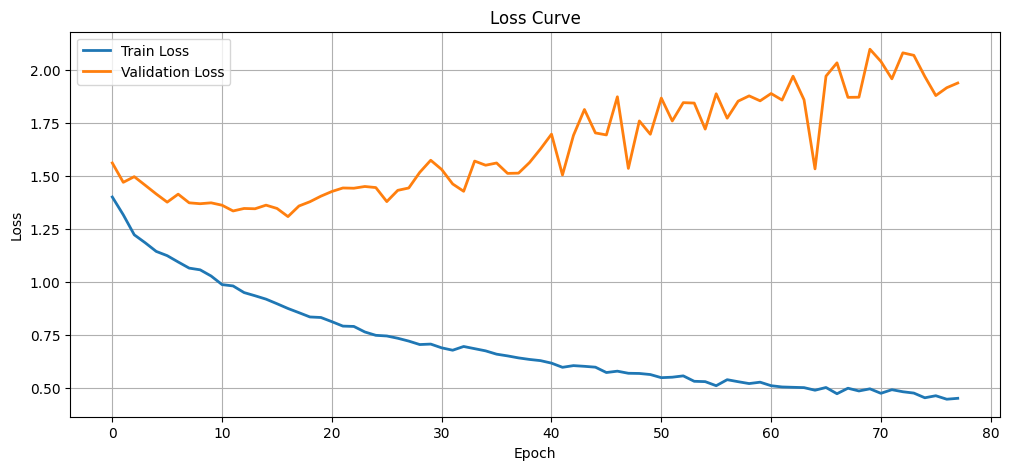

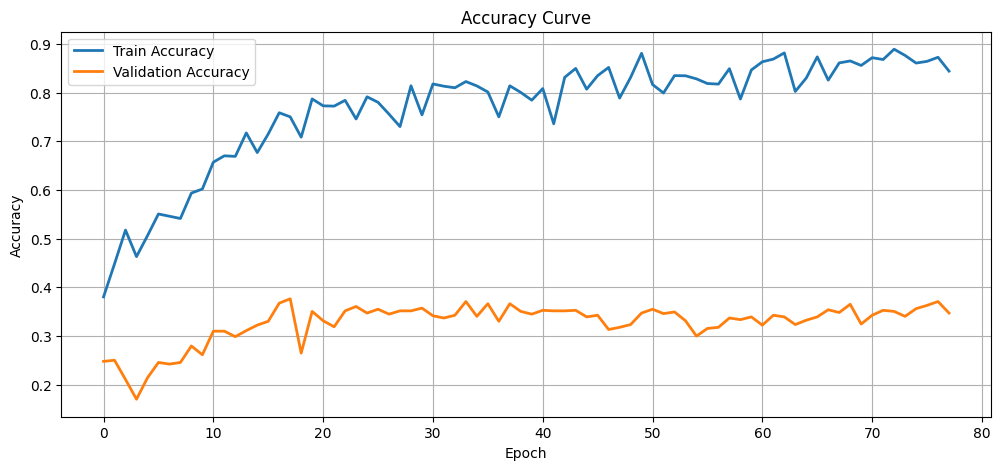

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(valid_losses, label='Validation Loss', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(valid_accs, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()